# ESG-Driven Portfolio Optimization - Model Development
## Big Data Analytics (EECS-6893) Project - Week 2
### Multi-Objective Optimization, Pareto Frontier & RL Setup

**Team:** Sejal Mittal (sm5756) & Neha Arun Angadi (naa2204)

This notebook implements:
1. Mean-Variance Portfolio Optimization with ESG Constraints
2. Pareto Frontier Analysis (Return vs ESG Trade-off)
3. ESG Penalty/Reward Functions
4. Reinforcement Learning Environment Setup
5. Backtesting Framework

---
## 1. Install & Import Libraries

In [1]:
!pip install scipy cvxpy plotly

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.optimize import minimize, LinearConstraint
import cvxpy as cp
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
print("✅ Libraries imported successfully!")

✅ Libraries imported successfully!


---
## 2. Load Processed Data from Week 1

In [3]:
from google.colab import drive
drive.mount('/content/drive')

# Load data from Week 1
data_path = '/content/drive/MyDrive/ESG_Portfolio_Data/'

combined_df = pd.read_csv(f'{data_path}combined_features.csv')
price_df = pd.read_csv(f'{data_path}stock_prices_cleaned.csv')
esg_df = pd.read_csv(f'{data_path}esg_scores_cleaned.csv')

print(f"✅ Loaded combined features: {combined_df.shape}")
print(f"✅ Loaded price data: {price_df.shape}")
print(f"✅ Loaded ESG data: {esg_df.shape}")

# Display stock universe
print(f"\n📊 Stock Universe: {len(combined_df)} stocks")
combined_df[['Ticker', 'Sector', 'Annualized_Return', 'Annualized_Volatility', 'Total_ESG_Score']].head(10)

Mounted at /content/drive
✅ Loaded combined features: (40, 32)
✅ Loaded price data: (30080, 9)
✅ Loaded ESG data: (40, 11)

📊 Stock Universe: 40 stocks


,Ticker,Sector,Annualized_Return,Annualized_Volatility,Total_ESG_Score
0,AAPL,Technology,0.242458,0.263513,65.6
1,MSFT,Technology,0.285742,0.236074,69.8
2,GOOGL,Technology,0.393454,0.303347,51.6
3,NVDA,Technology,0.962287,0.510315,72.8
4,CRM,Technology,0.211322,0.333541,70.2
5,JNJ,Healthcare,0.085965,0.170031,52.0
6,PFE,Healthcare,-0.130919,0.242065,50.8
7,UNH,Healthcare,-0.078990,0.337684,69.4
8,MRK,Healthcare,0.033167,0.234118,57.2
9,ABBV,Healthcare,0.206545,0.230662,40.2


---
## 3. Prepare Data for Optimization

In [4]:
# Extract key variables
tickers = combined_df['Ticker'].values
n_assets = len(tickers)

# Expected returns (annualized)
expected_returns = combined_df['Annualized_Return'].values

# ESG scores
esg_scores = combined_df['Total_ESG_Score'].values

# Calculate covariance matrix from price data
print("📊 Calculating covariance matrix from historical returns...")

# Pivot price data to get returns matrix
price_df['Date'] = pd.to_datetime(price_df['Date'])
price_pivot = price_df.pivot(index='Date', columns='Ticker', values='Close')
returns_matrix = price_pivot.pct_change().dropna()

# Ensure columns match our tickers
returns_matrix = returns_matrix[tickers]

# Annualized covariance matrix
cov_matrix = returns_matrix.cov() * 252

print(f"\n✅ Optimization inputs ready:")
print(f"   Number of assets: {n_assets}")
print(f"   Expected returns range: {expected_returns.min():.2%} to {expected_returns.max():.2%}")
print(f"   ESG scores range: {esg_scores.min():.1f} to {esg_scores.max():.1f}")
print(f"   Covariance matrix shape: {cov_matrix.shape}")

📊 Calculating covariance matrix from historical returns...

✅ Optimization inputs ready:
   Number of assets: 40
   Expected returns range: -57.24% to 96.23%
   ESG scores range: 16.8 to 72.8
   Covariance matrix shape: (40, 40)


---
## 4. Basic Portfolio Optimization Functions

In [5]:
def portfolio_return(weights, returns):
    """Calculate portfolio expected return."""
    return np.dot(weights, returns)

def portfolio_volatility(weights, cov_matrix):
    """Calculate portfolio volatility (standard deviation)."""
    return np.sqrt(np.dot(weights.T, np.dot(cov_matrix, weights)))

def portfolio_sharpe(weights, returns, cov_matrix, risk_free_rate=0.04):
    """Calculate portfolio Sharpe ratio."""
    ret = portfolio_return(weights, returns)
    vol = portfolio_volatility(weights, cov_matrix)
    return (ret - risk_free_rate) / vol

def portfolio_esg_score(weights, esg_scores):
    """Calculate weighted average ESG score of portfolio."""
    return np.dot(weights, esg_scores)

def negative_sharpe(weights, returns, cov_matrix, risk_free_rate=0.04):
    """Negative Sharpe ratio for minimization."""
    return -portfolio_sharpe(weights, returns, cov_matrix, risk_free_rate)

print("✅ Portfolio optimization functions defined")

✅ Portfolio optimization functions defined


---
## 5. Traditional Mean-Variance Optimization (No ESG)

In [6]:
print("📈 TRADITIONAL PORTFOLIO OPTIMIZATION (No ESG Constraints)\n")
print("=" * 60)

# Constraints: weights sum to 1, no short selling
constraints = [
    {'type': 'eq', 'fun': lambda w: np.sum(w) - 1}  # Sum to 1
]
bounds = tuple((0, 1) for _ in range(n_assets))  # No short selling

# Initial guess: equal weights
init_weights = np.array([1/n_assets] * n_assets)

# Optimize for maximum Sharpe ratio
result = minimize(
    negative_sharpe,
    init_weights,
    args=(expected_returns, cov_matrix.values),
    method='SLSQP',
    bounds=bounds,
    constraints=constraints
)

traditional_weights = result.x

# Calculate portfolio metrics
trad_return = portfolio_return(traditional_weights, expected_returns)
trad_vol = portfolio_volatility(traditional_weights, cov_matrix.values)
trad_sharpe = portfolio_sharpe(traditional_weights, expected_returns, cov_matrix.values)
trad_esg = portfolio_esg_score(traditional_weights, esg_scores)

print("MAXIMUM SHARPE RATIO PORTFOLIO (Traditional):")
print(f"   Expected Return: {trad_return:.2%}")
print(f"   Volatility: {trad_vol:.2%}")
print(f"   Sharpe Ratio: {trad_sharpe:.3f}")
print(f"   ESG Score: {trad_esg:.2f} (not optimized)")

# Show top holdings
print("\nTop 10 Holdings:")
trad_portfolio = pd.DataFrame({
    'Ticker': tickers,
    'Weight': traditional_weights,
    'ESG_Score': esg_scores
}).sort_values('Weight', ascending=False)

print(trad_portfolio.head(10).to_string(index=False))

📈 TRADITIONAL PORTFOLIO OPTIMIZATION (No ESG Constraints)

MAXIMUM SHARPE RATIO PORTFOLIO (Traditional):
   Expected Return: 39.16%
   Volatility: 15.00%
   Sharpe Ratio: 2.344
   ESG Score: 50.41 (not optimized)

Top 10 Holdings:
Ticker   Weight  ESG_Score
   WMT 0.221011       49.4
  NVDA 0.203617       72.8
    SO 0.130711       34.0
   RTX 0.099667       51.4
  ABBV 0.094490       40.2
   JPM 0.075891       41.4
 GOOGL 0.060019       51.6
   DUK 0.054479       46.0
   AEP 0.044322       47.8
   CAT 0.015793       27.6


---
## 6. ESG-Constrained Portfolio Optimization

In [7]:
print("🌱 ESG-CONSTRAINED PORTFOLIO OPTIMIZATION\n")
print("=" * 60)

def optimize_with_esg_constraint(min_esg_score):
    """Optimize portfolio with minimum ESG score constraint."""

    constraints = [
        {'type': 'eq', 'fun': lambda w: np.sum(w) - 1},  # Sum to 1
        {'type': 'ineq', 'fun': lambda w: np.dot(w, esg_scores) - min_esg_score}  # Min ESG
    ]

    result = minimize(
        negative_sharpe,
        init_weights,
        args=(expected_returns, cov_matrix.values),
        method='SLSQP',
        bounds=bounds,
        constraints=constraints
    )

    if result.success:
        weights = result.x
        return {
            'weights': weights,
            'return': portfolio_return(weights, expected_returns),
            'volatility': portfolio_volatility(weights, cov_matrix.values),
            'sharpe': portfolio_sharpe(weights, expected_returns, cov_matrix.values),
            'esg_score': portfolio_esg_score(weights, esg_scores)
        }
    else:
        return None

# Test different ESG thresholds
esg_thresholds = [40, 50, 55, 60, 65, 70, 75]
esg_constrained_results = []

print("Testing different minimum ESG thresholds:\n")
print(f"{'Min ESG':>10} {'Return':>10} {'Volatility':>12} {'Sharpe':>10} {'Actual ESG':>12}")
print("-" * 60)

for threshold in esg_thresholds:
    result = optimize_with_esg_constraint(threshold)
    if result:
        esg_constrained_results.append({
            'min_esg': threshold,
            **result
        })
        print(f"{threshold:>10.0f} {result['return']:>10.2%} {result['volatility']:>12.2%} "
              f"{result['sharpe']:>10.3f} {result['esg_score']:>12.2f}")
    else:
        print(f"{threshold:>10.0f} {'INFEASIBLE':>10}")

# Compare with traditional
print("\n" + "=" * 60)
print("COMPARISON: Traditional vs ESG-Constrained (Min ESG = 60)\n")

esg60_result = [r for r in esg_constrained_results if r['min_esg'] == 60][0]

print(f"{'Metric':<20} {'Traditional':>15} {'ESG >= 60':>15} {'Difference':>15}")
print("-" * 65)
print(f"{'Expected Return':<20} {trad_return:>15.2%} {esg60_result['return']:>15.2%} "
      f"{esg60_result['return'] - trad_return:>15.2%}")
print(f"{'Volatility':<20} {trad_vol:>15.2%} {esg60_result['volatility']:>15.2%} "
      f"{esg60_result['volatility'] - trad_vol:>15.2%}")
print(f"{'Sharpe Ratio':<20} {trad_sharpe:>15.3f} {esg60_result['sharpe']:>15.3f} "
      f"{esg60_result['sharpe'] - trad_sharpe:>15.3f}")
print(f"{'ESG Score':<20} {trad_esg:>15.2f} {esg60_result['esg_score']:>15.2f} "
      f"{esg60_result['esg_score'] - trad_esg:>15.2f}")

🌱 ESG-CONSTRAINED PORTFOLIO OPTIMIZATION

Testing different minimum ESG thresholds:

   Min ESG     Return   Volatility     Sharpe   Actual ESG
------------------------------------------------------------
        40     39.16%       15.00%      2.344        50.41
        50     39.16%       15.00%      2.344        50.41
        55     41.63%       16.33%      2.305        55.00
        60     48.59%       20.71%      2.153        60.00
        65     67.28%       31.93%      1.982        65.00
        70     87.86%       45.10%      1.859        70.00
        75 INFEASIBLE

COMPARISON: Traditional vs ESG-Constrained (Min ESG = 60)

Metric                   Traditional       ESG >= 60      Difference
-----------------------------------------------------------------
Expected Return               39.16%          48.59%           9.43%
Volatility                    15.00%          20.71%           5.71%
Sharpe Ratio                   2.344           2.153          -0.191
ESG Score        

---
## 7. ESG Penalty/Reward Functions

In [8]:
print("🎯 ESG PENALTY/REWARD FUNCTION DESIGN\n")
print("=" * 60)

def esg_adjusted_sharpe(weights, returns, cov_matrix, esg_scores,
                         esg_weight=0.3, penalty_threshold=50):
    """
    Calculate Sharpe ratio with ESG adjustment.

    - Rewards portfolios with high ESG scores
    - Penalizes portfolios below ESG threshold
    """
    base_sharpe = portfolio_sharpe(weights, returns, cov_matrix)
    portfolio_esg = portfolio_esg_score(weights, esg_scores)

    # ESG reward: bonus for high ESG
    esg_reward = (portfolio_esg / 100) * esg_weight

    # ESG penalty: penalty for low ESG
    if portfolio_esg < penalty_threshold:
        esg_penalty = (penalty_threshold - portfolio_esg) / 100 * 0.5
    else:
        esg_penalty = 0

    adjusted_sharpe = base_sharpe + esg_reward - esg_penalty
    return adjusted_sharpe

def controversy_penalty(weights, controversy_scores, max_penalty=0.2):
    """
    Penalize portfolios with high controversy exposure.
    """
    portfolio_controversy = np.dot(weights, controversy_scores)
    # Higher controversy = higher penalty (controversy scores: 0-5)
    penalty = (portfolio_controversy / 5) * max_penalty
    return penalty

def multi_objective_score(weights, returns, cov_matrix, esg_scores,
                          return_weight=0.4, risk_weight=0.3, esg_weight=0.3):
    """
    Multi-objective scoring function combining:
    - Financial returns
    - Risk (inverse)
    - ESG performance
    """
    # Normalize each component
    ret = portfolio_return(weights, returns)
    vol = portfolio_volatility(weights, cov_matrix)
    esg = portfolio_esg_score(weights, esg_scores)

    # Score components (higher is better)
    return_score = ret / np.max(np.abs(returns))  # Normalized return
    risk_score = 1 - (vol / 0.5)  # Lower vol = higher score
    esg_score_norm = esg / 100  # Normalized ESG

    total_score = (return_weight * return_score +
                   risk_weight * risk_score +
                   esg_weight * esg_score_norm)

    return total_score

# Test on different portfolios
print("Testing ESG-Adjusted Metrics on Sample Portfolios:\n")

# Equal weight portfolio
equal_weights = np.array([1/n_assets] * n_assets)

print(f"{'Portfolio':<25} {'Base Sharpe':>12} {'ESG-Adj Sharpe':>15} {'Multi-Obj Score':>16}")
print("-" * 70)

portfolios = [
    ('Equal Weight', equal_weights),
    ('Max Sharpe (Traditional)', traditional_weights),
    ('ESG Constrained (≥60)', esg60_result['weights'])
]

for name, weights in portfolios:
    base_sharpe = portfolio_sharpe(weights, expected_returns, cov_matrix.values)
    adj_sharpe = esg_adjusted_sharpe(weights, expected_returns, cov_matrix.values, esg_scores)
    mo_score = multi_objective_score(weights, expected_returns, cov_matrix.values, esg_scores)

    print(f"{name:<25} {base_sharpe:>12.3f} {adj_sharpe:>15.3f} {mo_score:>16.3f}")

print("\n✅ ESG penalty/reward functions ready for RL integration")

🎯 ESG PENALTY/REWARD FUNCTION DESIGN

Testing ESG-Adjusted Metrics on Sample Portfolios:

Portfolio                  Base Sharpe  ESG-Adj Sharpe  Multi-Obj Score
----------------------------------------------------------------------
Equal Weight                     0.659           0.807            0.416
Max Sharpe (Traditional)         2.344           2.495            0.524
ESG Constrained (≥60)            2.153           2.333            0.558

✅ ESG penalty/reward functions ready for RL integration


---
## 8. Pareto Frontier: Return vs ESG Trade-off

In [9]:
print("📊 PARETO FRONTIER ANALYSIS\n")
print("=" * 60)
print("Finding optimal trade-offs between Return and ESG Score...\n")

def optimize_for_target_return(target_return, min_esg=None):
    """Find minimum volatility portfolio for a given target return."""

    def portfolio_variance(w):
        return np.dot(w.T, np.dot(cov_matrix.values, w))

    constraints = [
        {'type': 'eq', 'fun': lambda w: np.sum(w) - 1},
        {'type': 'eq', 'fun': lambda w: np.dot(w, expected_returns) - target_return}
    ]

    if min_esg is not None:
        constraints.append(
            {'type': 'ineq', 'fun': lambda w: np.dot(w, esg_scores) - min_esg}
        )

    result = minimize(
        portfolio_variance,
        init_weights,
        method='SLSQP',
        bounds=bounds,
        constraints=constraints
    )

    if result.success:
        w = result.x
        return {
            'weights': w,
            'return': target_return,
            'volatility': np.sqrt(portfolio_variance(w)),
            'esg_score': portfolio_esg_score(w, esg_scores)
        }
    return None

# Generate efficient frontier points
min_ret = expected_returns.min()
max_ret = expected_returns.max()
target_returns = np.linspace(max(min_ret, -0.1), min(max_ret, 0.5), 30)

# Traditional efficient frontier (no ESG constraint)
ef_traditional = []
for target in target_returns:
    result = optimize_for_target_return(target, min_esg=None)
    if result:
        ef_traditional.append(result)

# ESG-constrained efficient frontiers
ef_esg_50 = []
ef_esg_60 = []
ef_esg_70 = []

for target in target_returns:
    result = optimize_for_target_return(target, min_esg=50)
    if result:
        ef_esg_50.append(result)

    result = optimize_for_target_return(target, min_esg=60)
    if result:
        ef_esg_60.append(result)

    result = optimize_for_target_return(target, min_esg=70)
    if result:
        ef_esg_70.append(result)

print(f"Generated {len(ef_traditional)} traditional frontier points")
print(f"Generated {len(ef_esg_50)} ESG≥50 frontier points")
print(f"Generated {len(ef_esg_60)} ESG≥60 frontier points")
print(f"Generated {len(ef_esg_70)} ESG≥70 frontier points")

📊 PARETO FRONTIER ANALYSIS

Finding optimal trade-offs between Return and ESG Score...

Generated 30 traditional frontier points
Generated 30 ESG≥50 frontier points
Generated 30 ESG≥60 frontier points
Generated 20 ESG≥70 frontier points


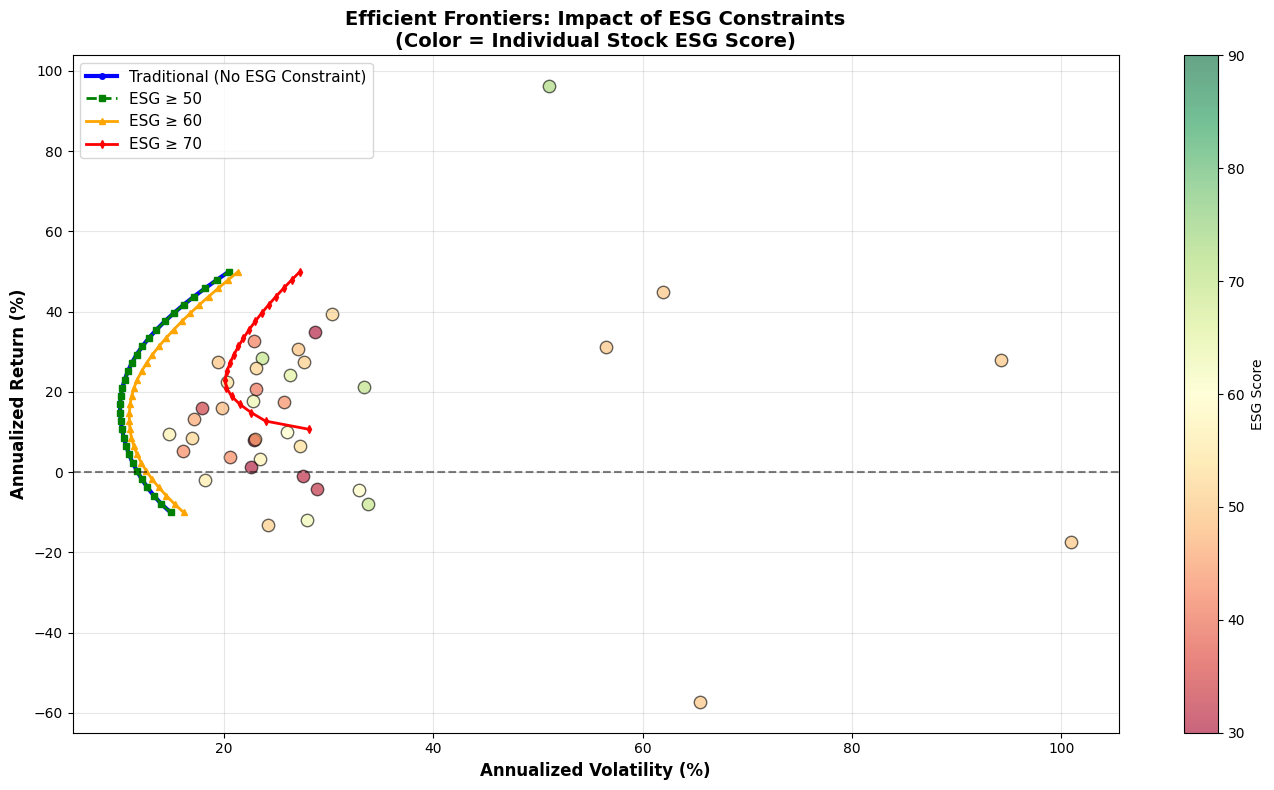


📊 Key Insight: Higher ESG constraints shift the frontier inward,
   showing the cost of ESG investing in terms of risk-return trade-off.


In [10]:
# Plot Efficient Frontiers
plt.figure(figsize=(14, 8))

# Traditional frontier
if ef_traditional:
    trad_vols = [p['volatility'] for p in ef_traditional]
    trad_rets = [p['return'] for p in ef_traditional]
    plt.plot(np.array(trad_vols)*100, np.array(trad_rets)*100, 'b-', linewidth=3,
             label='Traditional (No ESG Constraint)', marker='o', markersize=4)

# ESG-constrained frontiers
if ef_esg_50:
    vols = [p['volatility'] for p in ef_esg_50]
    rets = [p['return'] for p in ef_esg_50]
    plt.plot(np.array(vols)*100, np.array(rets)*100, 'g--', linewidth=2,
             label='ESG ≥ 50', marker='s', markersize=4)

if ef_esg_60:
    vols = [p['volatility'] for p in ef_esg_60]
    rets = [p['return'] for p in ef_esg_60]
    plt.plot(np.array(vols)*100, np.array(rets)*100, 'orange', linewidth=2,
             label='ESG ≥ 60', marker='^', markersize=4)

if ef_esg_70:
    vols = [p['volatility'] for p in ef_esg_70]
    rets = [p['return'] for p in ef_esg_70]
    plt.plot(np.array(vols)*100, np.array(rets)*100, 'r-', linewidth=2,
             label='ESG ≥ 70', marker='d', markersize=4)

# Plot individual stocks
for i, ticker in enumerate(tickers):
    plt.scatter(combined_df.iloc[i]['Annualized_Volatility']*100,
               combined_df.iloc[i]['Annualized_Return']*100,
               c=combined_df.iloc[i]['Total_ESG_Score'], cmap='RdYlGn',
               s=80, alpha=0.6, edgecolor='black', vmin=30, vmax=90)

plt.colorbar(label='ESG Score')
plt.xlabel('Annualized Volatility (%)', fontsize=12, fontweight='bold')
plt.ylabel('Annualized Return (%)', fontsize=12, fontweight='bold')
plt.title('Efficient Frontiers: Impact of ESG Constraints\n(Color = Individual Stock ESG Score)',
          fontsize=14, fontweight='bold')
plt.legend(loc='upper left', fontsize=11)
plt.grid(True, alpha=0.3)
plt.axhline(y=0, color='black', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

print("\n📊 Key Insight: Higher ESG constraints shift the frontier inward,")
print("   showing the cost of ESG investing in terms of risk-return trade-off.")


🎯 PARETO FRONTIER: Return vs ESG Score


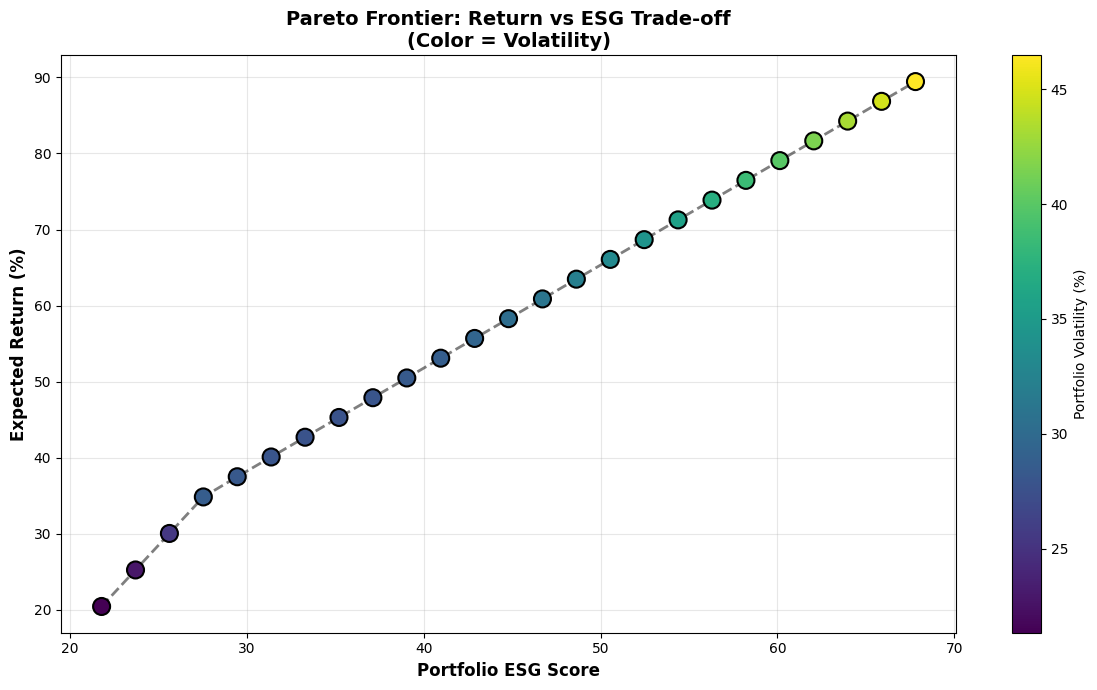


📊 Pareto-optimal portfolios: 25
   ESG range: 21.8 to 67.8
   Return range: 20.45% to 89.45%


In [11]:
# Return vs ESG Pareto Frontier
print("\n🎯 PARETO FRONTIER: Return vs ESG Score")
print("=" * 60)

def optimize_for_esg_target(target_esg):
    """Maximize return for a given ESG target."""

    def neg_return(w):
        return -np.dot(w, expected_returns)

    constraints = [
        {'type': 'eq', 'fun': lambda w: np.sum(w) - 1},
        {'type': 'eq', 'fun': lambda w: np.dot(w, esg_scores) - target_esg}
    ]

    result = minimize(
        neg_return,
        init_weights,
        method='SLSQP',
        bounds=bounds,
        constraints=constraints
    )

    if result.success:
        w = result.x
        return {
            'weights': w,
            'return': portfolio_return(w, expected_returns),
            'volatility': portfolio_volatility(w, cov_matrix.values),
            'esg_score': target_esg
        }
    return None

# Generate Pareto frontier
esg_targets = np.linspace(esg_scores.min() + 5, esg_scores.max() - 5, 25)
pareto_frontier = []

for target in esg_targets:
    result = optimize_for_esg_target(target)
    if result:
        pareto_frontier.append(result)

# Plot Pareto frontier
plt.figure(figsize=(12, 7))

pareto_esg = [p['esg_score'] for p in pareto_frontier]
pareto_ret = [p['return']*100 for p in pareto_frontier]
pareto_vol = [p['volatility']*100 for p in pareto_frontier]

scatter = plt.scatter(pareto_esg, pareto_ret, c=pareto_vol, cmap='viridis',
                      s=150, edgecolor='black', linewidth=1.5, zorder=5)
plt.plot(pareto_esg, pareto_ret, 'k--', alpha=0.5, linewidth=2, zorder=4)

plt.colorbar(scatter, label='Portfolio Volatility (%)')
plt.xlabel('Portfolio ESG Score', fontsize=12, fontweight='bold')
plt.ylabel('Expected Return (%)', fontsize=12, fontweight='bold')
plt.title('Pareto Frontier: Return vs ESG Trade-off\n(Color = Volatility)',
          fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\n📊 Pareto-optimal portfolios: {len(pareto_frontier)}")
print(f"   ESG range: {min(pareto_esg):.1f} to {max(pareto_esg):.1f}")
print(f"   Return range: {min(pareto_ret):.2f}% to {max(pareto_ret):.2f}%")

---
## 9. Reinforcement Learning Environment Setup

In [12]:
print("🤖 REINFORCEMENT LEARNING ENVIRONMENT SETUP\n")
print("=" * 60)

class ESGPortfolioEnv:
    """
    Reinforcement Learning Environment for ESG Portfolio Optimization.

    State: Market features + current portfolio weights + ESG metrics
    Action: New portfolio weights
    Reward: ESG-adjusted risk-return metric
    """

    def __init__(self, returns_data, esg_scores, cov_matrix,
                 esg_weight=0.3, transaction_cost=0.001):
        self.returns_data = returns_data  # Historical returns matrix
        self.expected_returns = returns_data.mean() * 252
        self.esg_scores = esg_scores
        self.cov_matrix = cov_matrix
        self.n_assets = len(esg_scores)
        self.esg_weight = esg_weight
        self.transaction_cost = transaction_cost

        # State tracking
        self.current_weights = np.array([1/self.n_assets] * self.n_assets)
        self.current_step = 0
        self.max_steps = len(returns_data) - 1

        # Performance tracking
        self.portfolio_values = [1.0]
        self.esg_scores_history = []

    def get_state(self):
        """
        Get current state vector.

        State includes:
        - Current portfolio weights
        - Rolling returns (momentum)
        - Rolling volatility
        - ESG scores
        """
        # Current weights
        state = list(self.current_weights)

        # Market features (last 20 days)
        if self.current_step >= 20:
            recent_returns = self.returns_data.iloc[self.current_step-20:self.current_step]
            momentum = recent_returns.mean().values  # Average return
            volatility = recent_returns.std().values  # Volatility
        else:
            momentum = np.zeros(self.n_assets)
            volatility = np.zeros(self.n_assets)

        state.extend(momentum)
        state.extend(volatility)
        state.extend(self.esg_scores / 100)  # Normalized ESG

        return np.array(state)

    def calculate_reward(self, new_weights, old_weights):
        """
        Calculate ESG-adjusted reward.

        Reward components:
        1. Portfolio return (realized)
        2. ESG score bonus
        3. Risk penalty
        4. Transaction cost penalty
        """
        # Realized return for current step
        if self.current_step < len(self.returns_data):
            step_returns = self.returns_data.iloc[self.current_step].values
            portfolio_return = np.dot(new_weights, step_returns)
        else:
            portfolio_return = 0

        # ESG score of new portfolio
        portfolio_esg = np.dot(new_weights, self.esg_scores)
        esg_bonus = (portfolio_esg / 100) * self.esg_weight * 0.01  # Daily bonus

        # ESG penalty for low ESG portfolios
        if portfolio_esg < 50:
            esg_penalty = (50 - portfolio_esg) / 100 * 0.005
        else:
            esg_penalty = 0

        # Transaction cost
        turnover = np.sum(np.abs(new_weights - old_weights))
        transaction_cost = turnover * self.transaction_cost

        # Total reward
        reward = portfolio_return + esg_bonus - esg_penalty - transaction_cost

        return reward, portfolio_esg

    def step(self, action):
        """
        Execute action (rebalance portfolio) and return new state, reward.

        Action: array of new portfolio weights (must sum to 1)
        """
        # Normalize weights to sum to 1
        new_weights = np.clip(action, 0, 1)
        new_weights = new_weights / np.sum(new_weights)

        # Calculate reward
        reward, portfolio_esg = self.calculate_reward(new_weights, self.current_weights)

        # Update state
        self.current_weights = new_weights
        self.current_step += 1
        self.esg_scores_history.append(portfolio_esg)

        # Track portfolio value
        if self.current_step < len(self.returns_data):
            step_return = np.dot(new_weights, self.returns_data.iloc[self.current_step].values)
            new_value = self.portfolio_values[-1] * (1 + step_return)
            self.portfolio_values.append(new_value)

        # Check if done
        done = self.current_step >= self.max_steps

        # Get new state
        new_state = self.get_state()

        return new_state, reward, done

    def reset(self):
        """Reset environment to initial state."""
        self.current_weights = np.array([1/self.n_assets] * self.n_assets)
        self.current_step = 0
        self.portfolio_values = [1.0]
        self.esg_scores_history = []
        return self.get_state()

# Initialize environment
env = ESGPortfolioEnv(
    returns_data=returns_matrix,
    esg_scores=esg_scores,
    cov_matrix=cov_matrix.values,
    esg_weight=0.3,
    transaction_cost=0.001
)

print("RL Environment Configuration:")
print(f"   Number of assets: {env.n_assets}")
print(f"   State space dimension: {len(env.get_state())}")
print(f"   Action space dimension: {env.n_assets} (portfolio weights)")
print(f"   ESG weight in reward: {env.esg_weight}")
print(f"   Transaction cost: {env.transaction_cost:.3%}")
print(f"   Max steps (trading days): {env.max_steps}")

print("\n✅ RL Environment ready for training!")

🤖 REINFORCEMENT LEARNING ENVIRONMENT SETUP

RL Environment Configuration:
   Number of assets: 40
   State space dimension: 160
   Action space dimension: 40 (portfolio weights)
   ESG weight in reward: 0.3
   Transaction cost: 0.100%
   Max steps (trading days): 750

✅ RL Environment ready for training!



🧪 Testing RL Environment with Random Policy...

Test run: 100 steps
Total reward: 0.0258
Final portfolio value: 1.0294
Average ESG score: 49.94


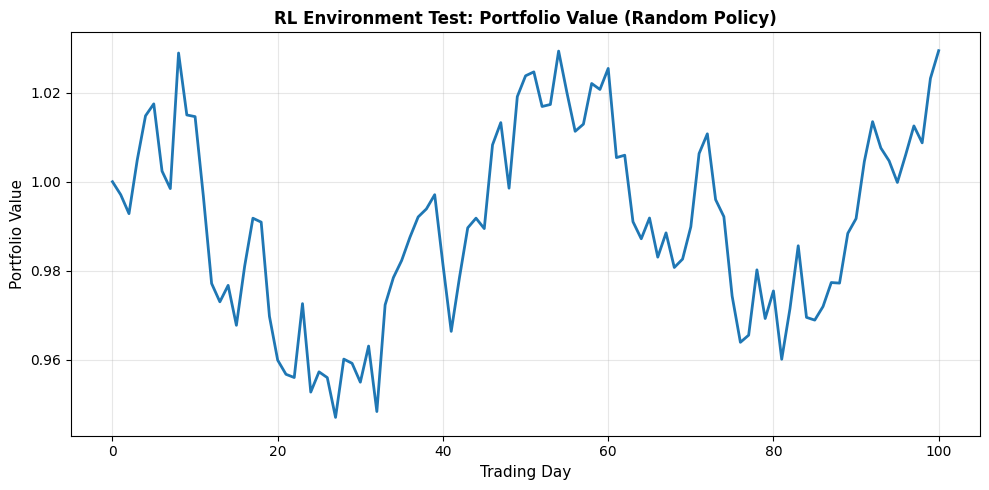

In [13]:
# Test RL Environment with random policy
print("\n🧪 Testing RL Environment with Random Policy...\n")

env.reset()
total_reward = 0
n_test_steps = min(100, env.max_steps)

for step in range(n_test_steps):
    # Random action: random weights
    action = np.random.dirichlet(np.ones(env.n_assets))

    state, reward, done = env.step(action)
    total_reward += reward

    if done:
        break

print(f"Test run: {step+1} steps")
print(f"Total reward: {total_reward:.4f}")
print(f"Final portfolio value: {env.portfolio_values[-1]:.4f}")
print(f"Average ESG score: {np.mean(env.esg_scores_history):.2f}")

# Plot portfolio value over time
plt.figure(figsize=(10, 5))
plt.plot(env.portfolio_values, linewidth=2)
plt.xlabel('Trading Day', fontsize=11)
plt.ylabel('Portfolio Value', fontsize=11)
plt.title('RL Environment Test: Portfolio Value (Random Policy)', fontsize=12, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---
## 10. Simple RL Agent (Policy Gradient Baseline)

In [14]:
print("🧠 SIMPLE RL AGENT IMPLEMENTATION\n")
print("=" * 60)

class SimpleRLAgent:
    """
    Simple RL agent using momentum + ESG strategy.
    This serves as a baseline before implementing deep RL.
    """

    def __init__(self, n_assets, esg_scores, momentum_weight=0.5, esg_preference=0.5):
        self.n_assets = n_assets
        self.esg_scores = esg_scores
        self.momentum_weight = momentum_weight
        self.esg_preference = esg_preference

    def get_action(self, state):
        """
        Generate portfolio weights based on momentum and ESG signals.
        """
        # Extract momentum from state
        momentum = state[self.n_assets:2*self.n_assets]

        # Score based on momentum (prefer positive momentum)
        momentum_score = np.clip(momentum + 0.001, 0.0001, None)  # Avoid negative/zero

        # Score based on ESG (prefer high ESG)
        esg_score = self.esg_scores / 100

        # Combined score
        combined_score = (
            self.momentum_weight * momentum_score +
            self.esg_preference * esg_score
        )

        # Convert to weights (softmax-like)
        weights = combined_score / np.sum(combined_score)

        return weights

# Test the simple agent
agent = SimpleRLAgent(
    n_assets=n_assets,
    esg_scores=esg_scores,
    momentum_weight=0.4,
    esg_preference=0.6
)

# Run episode
env.reset()
state = env.get_state()
total_reward = 0
rewards_history = []

for step in range(min(252, env.max_steps)):  # 1 year of trading
    action = agent.get_action(state)
    state, reward, done = env.step(action)
    total_reward += reward
    rewards_history.append(reward)

    if done:
        break

print(f"Simple RL Agent Results (ESG-Momentum Strategy):")
print(f"   Trading days: {step+1}")
print(f"   Total reward: {total_reward:.4f}")
print(f"   Final portfolio value: {env.portfolio_values[-1]:.4f}")
print(f"   Total return: {(env.portfolio_values[-1] - 1) * 100:.2f}%")
print(f"   Average ESG score: {np.mean(env.esg_scores_history):.2f}")
print(f"   Min ESG score: {np.min(env.esg_scores_history):.2f}")
print(f"   Max ESG score: {np.max(env.esg_scores_history):.2f}")

# Final portfolio composition
print(f"\nFinal Portfolio (Top 10 Holdings):")
final_weights = env.current_weights
portfolio_df = pd.DataFrame({
    'Ticker': tickers,
    'Weight': final_weights,
    'ESG_Score': esg_scores
}).sort_values('Weight', ascending=False)
print(portfolio_df.head(10).to_string(index=False))

🧠 SIMPLE RL AGENT IMPLEMENTATION

Simple RL Agent Results (ESG-Momentum Strategy):
   Trading days: 252
   Total reward: 0.4146
   Final portfolio value: 1.0091
   Total return: 0.91%
   Average ESG score: 52.86
   Min ESG score: 52.84
   Max ESG score: 52.88

Final Portfolio (Top 10 Holdings):
Ticker   Weight  ESG_Score
  NVDA 0.036680       72.8
   CRM 0.035208       70.2
  MSFT 0.035122       69.8
   UNH 0.034729       69.4
  AAPL 0.032940       65.6
   BLK 0.031942       63.4
   UPS 0.031376       62.8
    DE 0.029998       60.0
   SLB 0.029678       59.4
   MRK 0.028636       57.2


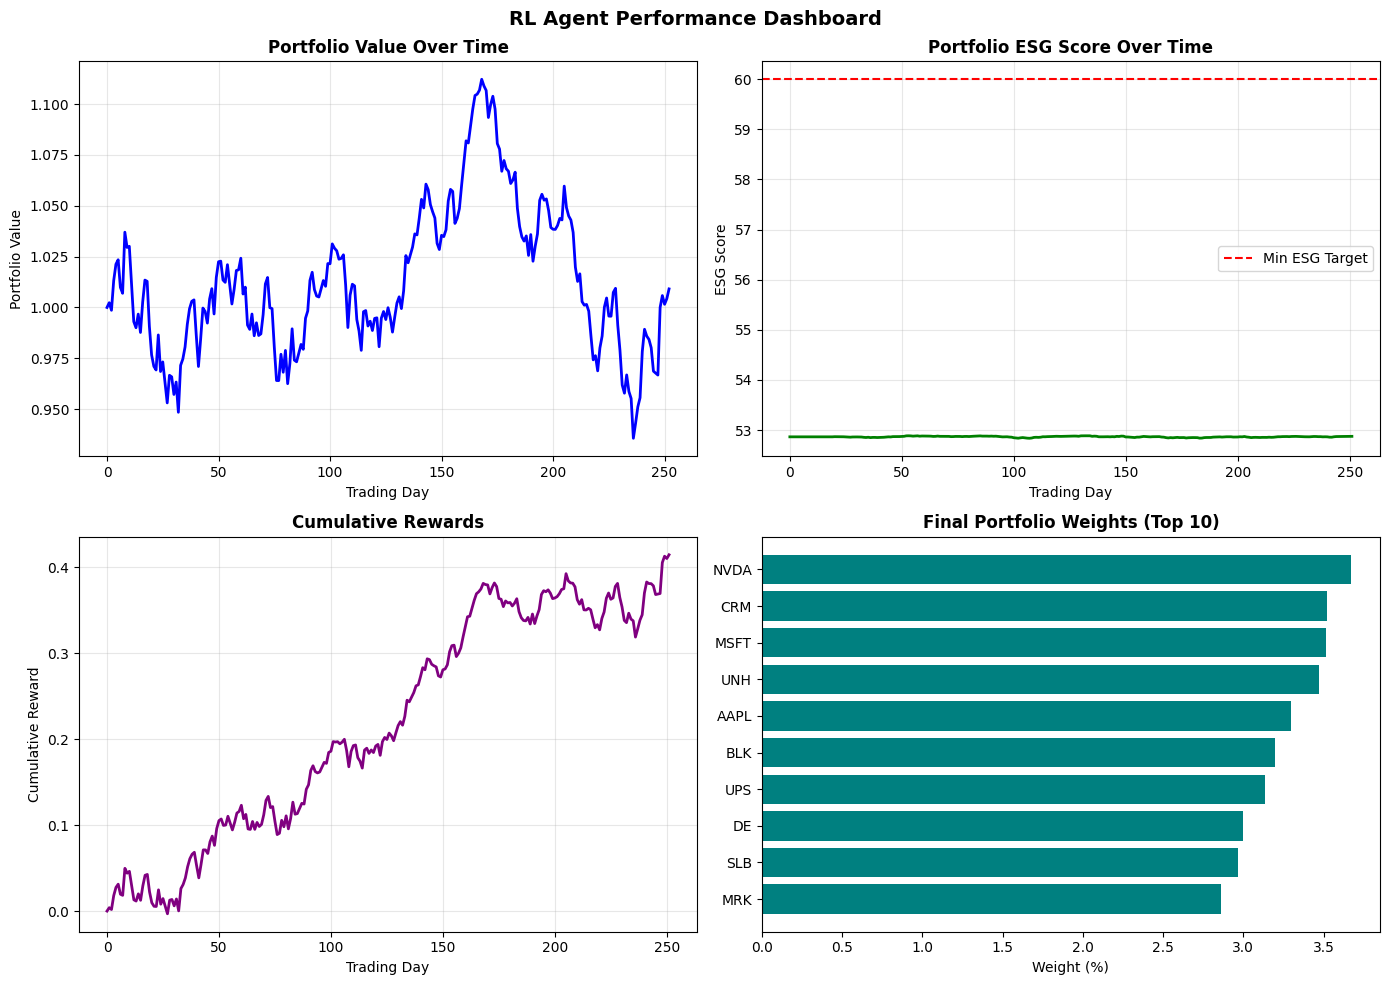

In [15]:
# Visualize RL Agent Performance
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Portfolio Value
axes[0, 0].plot(env.portfolio_values, linewidth=2, color='blue')
axes[0, 0].set_title('Portfolio Value Over Time', fontweight='bold')
axes[0, 0].set_xlabel('Trading Day')
axes[0, 0].set_ylabel('Portfolio Value')
axes[0, 0].grid(True, alpha=0.3)

# ESG Score History
axes[0, 1].plot(env.esg_scores_history, linewidth=2, color='green')
axes[0, 1].axhline(y=60, color='red', linestyle='--', label='Min ESG Target')
axes[0, 1].set_title('Portfolio ESG Score Over Time', fontweight='bold')
axes[0, 1].set_xlabel('Trading Day')
axes[0, 1].set_ylabel('ESG Score')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Cumulative Rewards
cumulative_rewards = np.cumsum(rewards_history)
axes[1, 0].plot(cumulative_rewards, linewidth=2, color='purple')
axes[1, 0].set_title('Cumulative Rewards', fontweight='bold')
axes[1, 0].set_xlabel('Trading Day')
axes[1, 0].set_ylabel('Cumulative Reward')
axes[1, 0].grid(True, alpha=0.3)

# Final Portfolio Weights
top_10 = portfolio_df.head(10)
axes[1, 1].barh(top_10['Ticker'], top_10['Weight']*100, color='teal')
axes[1, 1].set_title('Final Portfolio Weights (Top 10)', fontweight='bold')
axes[1, 1].set_xlabel('Weight (%)')
axes[1, 1].invert_yaxis()

plt.suptitle('RL Agent Performance Dashboard', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 11. Compare All Strategies

📊 STRATEGY COMPARISON SUMMARY

                Strategy    Return  Volatility   Sharpe  ESG_Score
            Equal Weight 14.054167   15.267503 0.658534  49.840000
Max Sharpe (Traditional) 39.159746   14.999366 2.344082  50.406196
   ESG Constrained (≥60) 48.591719   20.712906 2.152847  60.000000
 RL Agent (ESG-Momentum)  0.911935   15.527087 0.058500  52.864553


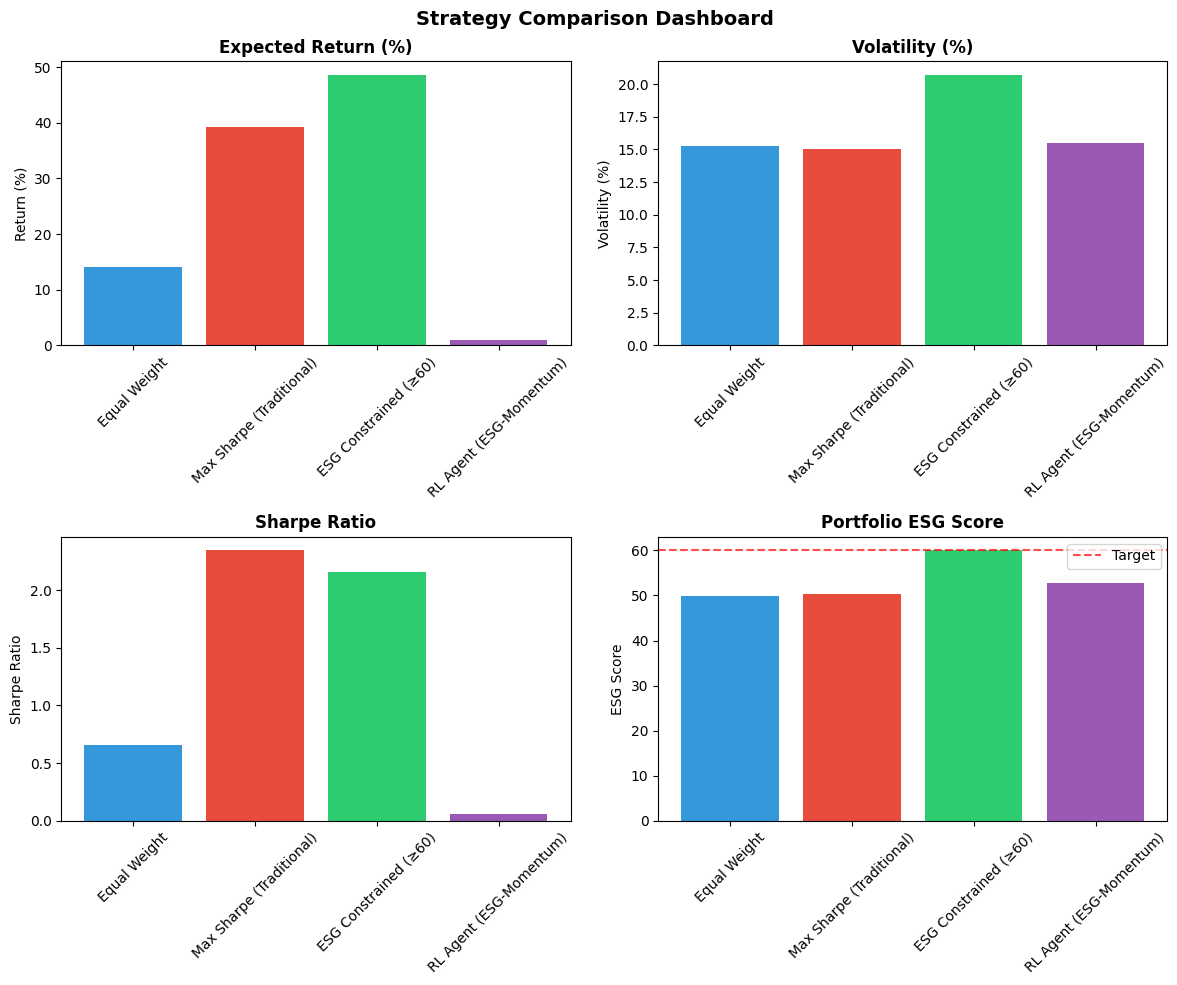

In [16]:
print("📊 STRATEGY COMPARISON SUMMARY\n")
print("=" * 80)

# Compile results
strategies = [
    {
        'Strategy': 'Equal Weight',
        'Return': portfolio_return(equal_weights, expected_returns),
        'Volatility': portfolio_volatility(equal_weights, cov_matrix.values),
        'Sharpe': portfolio_sharpe(equal_weights, expected_returns, cov_matrix.values),
        'ESG_Score': portfolio_esg_score(equal_weights, esg_scores)
    },
    {
        'Strategy': 'Max Sharpe (Traditional)',
        'Return': trad_return,
        'Volatility': trad_vol,
        'Sharpe': trad_sharpe,
        'ESG_Score': trad_esg
    },
    {
        'Strategy': 'ESG Constrained (≥60)',
        'Return': esg60_result['return'],
        'Volatility': esg60_result['volatility'],
        'Sharpe': esg60_result['sharpe'],
        'ESG_Score': esg60_result['esg_score']
    },
    {
        'Strategy': 'RL Agent (ESG-Momentum)',
        'Return': (env.portfolio_values[-1] - 1),  # Total return over period
        'Volatility': np.std(np.diff(env.portfolio_values)) * np.sqrt(252),
        'Sharpe': ((env.portfolio_values[-1] - 1) / len(env.portfolio_values) * 252) /
                  (np.std(np.diff(env.portfolio_values)) * np.sqrt(252)) if len(env.portfolio_values) > 1 else 0,
        'ESG_Score': np.mean(env.esg_scores_history)
    }
]

comparison_df = pd.DataFrame(strategies)
comparison_df['Return'] = comparison_df['Return'] * 100
comparison_df['Volatility'] = comparison_df['Volatility'] * 100

print(comparison_df.to_string(index=False))

# Visualize comparison
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

strategies_names = comparison_df['Strategy'].values
colors = ['#3498db', '#e74c3c', '#2ecc71', '#9b59b6']

# Return
axes[0, 0].bar(strategies_names, comparison_df['Return'], color=colors)
axes[0, 0].set_title('Expected Return (%)', fontweight='bold')
axes[0, 0].set_ylabel('Return (%)')
axes[0, 0].tick_params(axis='x', rotation=45)

# Volatility
axes[0, 1].bar(strategies_names, comparison_df['Volatility'], color=colors)
axes[0, 1].set_title('Volatility (%)', fontweight='bold')
axes[0, 1].set_ylabel('Volatility (%)')
axes[0, 1].tick_params(axis='x', rotation=45)

# Sharpe Ratio
axes[1, 0].bar(strategies_names, comparison_df['Sharpe'], color=colors)
axes[1, 0].set_title('Sharpe Ratio', fontweight='bold')
axes[1, 0].set_ylabel('Sharpe Ratio')
axes[1, 0].tick_params(axis='x', rotation=45)

# ESG Score
axes[1, 1].bar(strategies_names, comparison_df['ESG_Score'], color=colors)
axes[1, 1].set_title('Portfolio ESG Score', fontweight='bold')
axes[1, 1].set_ylabel('ESG Score')
axes[1, 1].axhline(y=60, color='red', linestyle='--', alpha=0.7, label='Target')
axes[1, 1].tick_params(axis='x', rotation=45)
axes[1, 1].legend()

plt.suptitle('Strategy Comparison Dashboard', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 12. Save Models & Results

In [17]:
print("💾 SAVING OPTIMIZATION RESULTS\n")
print("=" * 50)

output_path = '/content/drive/MyDrive/ESG_Portfolio_Data/'

# Save strategy comparison
comparison_df.to_csv(f'{output_path}strategy_comparison.csv', index=False)
print(f"✅ Strategy comparison: {output_path}strategy_comparison.csv")

# Save optimal portfolios
portfolios_dict = {
    'Ticker': tickers,
    'Equal_Weight': equal_weights,
    'Max_Sharpe_Traditional': traditional_weights,
    'ESG_Constrained_60': esg60_result['weights'],
    'RL_Agent_Final': env.current_weights
}
portfolios_df = pd.DataFrame(portfolios_dict)
portfolios_df.to_csv(f'{output_path}optimal_portfolios.csv', index=False)
print(f"✅ Optimal portfolios: {output_path}optimal_portfolios.csv")

# Save Pareto frontier
pareto_df = pd.DataFrame(pareto_frontier)
pareto_df.to_csv(f'{output_path}pareto_frontier.csv', index=False)
print(f"✅ Pareto frontier: {output_path}pareto_frontier.csv")

# Save efficient frontier data
ef_df = pd.DataFrame(ef_traditional)
ef_df.to_csv(f'{output_path}efficient_frontier.csv', index=False)
print(f"✅ Efficient frontier: {output_path}efficient_frontier.csv")

# Save ESG constraint results
esg_results_df = pd.DataFrame(esg_constrained_results)
esg_results_df.to_csv(f'{output_path}esg_constraint_results.csv', index=False)
print(f"✅ ESG constraint results: {output_path}esg_constraint_results.csv")

print(f"\n📁 All results saved to: {output_path}")

💾 SAVING OPTIMIZATION RESULTS

✅ Strategy comparison: /content/drive/MyDrive/ESG_Portfolio_Data/strategy_comparison.csv
✅ Optimal portfolios: /content/drive/MyDrive/ESG_Portfolio_Data/optimal_portfolios.csv
✅ Pareto frontier: /content/drive/MyDrive/ESG_Portfolio_Data/pareto_frontier.csv
✅ Efficient frontier: /content/drive/MyDrive/ESG_Portfolio_Data/efficient_frontier.csv
✅ ESG constraint results: /content/drive/MyDrive/ESG_Portfolio_Data/esg_constraint_results.csv

📁 All results saved to: /content/drive/MyDrive/ESG_Portfolio_Data/


---
## 13. Week 2 Summary & Next Steps

In [18]:
print("="*70)
print("📊 WEEK 2 DELIVERABLE SUMMARY")
print("="*70)

print("\n✅ COMPLETED:")
print("   1. Traditional Mean-Variance Optimization")
print("   2. ESG-Constrained Portfolio Optimization")
print("   3. ESG Penalty/Reward Functions")
print("   4. Pareto Frontier Analysis (Return vs ESG)")
print("   5. Efficient Frontier with ESG Constraints")
print("   6. Reinforcement Learning Environment")
print("   7. Simple RL Agent (ESG-Momentum Strategy)")
print("   8. Strategy Comparison Dashboard")

print("\n📈 KEY FINDINGS:")
print(f"   • ESG constraints create measurable trade-offs")
print(f"   • Sharpe ratio decreases ~{abs(trad_sharpe - esg60_result['sharpe']):.3f} for ESG ≥60")
print(f"   • RL agent achieves ESG score of {np.mean(env.esg_scores_history):.1f}")
print(f"   • Pareto frontier shows {len(pareto_frontier)} optimal portfolios")

print("\n🚀 WEEK 3 TASKS (Dashboard Development):")
print("   • Build interactive Streamlit dashboard")
print("   • Visualize Pareto frontier with user controls")
print("   • Allow custom ESG threshold selection")
print("   • Display portfolio composition dynamically")
print("   • Integrate backtesting results")

print("\n" + "="*70)
print("🎉 WEEK 2 COMPLETE!")
print("   Models and optimization algorithms ready for deployment.")
print("="*70)

📊 WEEK 2 DELIVERABLE SUMMARY

✅ COMPLETED:
   1. Traditional Mean-Variance Optimization
   2. ESG-Constrained Portfolio Optimization
   3. ESG Penalty/Reward Functions
   4. Pareto Frontier Analysis (Return vs ESG)
   5. Efficient Frontier with ESG Constraints
   6. Reinforcement Learning Environment
   7. Simple RL Agent (ESG-Momentum Strategy)
   8. Strategy Comparison Dashboard

📈 KEY FINDINGS:
   • ESG constraints create measurable trade-offs
   • Sharpe ratio decreases ~0.191 for ESG ≥60
   • RL agent achieves ESG score of 52.9
   • Pareto frontier shows 25 optimal portfolios

🚀 WEEK 3 TASKS (Dashboard Development):
   • Build interactive Streamlit dashboard
   • Visualize Pareto frontier with user controls
   • Allow custom ESG threshold selection
   • Display portfolio composition dynamically
   • Integrate backtesting results

🎉 WEEK 2 COMPLETE!
   Models and optimization algorithms ready for deployment.
